In [2]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shivamsingh163248","key":"0bfc139106712f4147f0158bd716481d"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
!pip install -q kaggle

In [5]:
!kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0


In [6]:
!unzip dog-and-cat-classification-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/5499.jpg  
  inflating: PetImages/Dog/55.jpg    
  inflating: PetImages/Dog/550.jpg   
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   

In [7]:
# Step 1: Import necessary modules for CNN

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Confirm successful import
print("All necessary modules imported successfully for CNN")


All necessary modules imported successfully for CNN


In [8]:
# import os
# import cv2
# import numpy as np
# from tqdm import tqdm

# # Set your dataset path
# cat_folder = "/content/PetImages/Cat"
# dog_folder = "/content/PetImages/Dog"

# # Set image size
# IMG_SIZE = 128

# # Initialize data and labels
# X = []  # image data
# y = []  # labels

# # Helper function to load and preprocess images
# def load_images_from_folder(folder, label):
#     for filename in tqdm(os.listdir(folder)):
#         if filename.endswith(".jpg"):
#             img_path = os.path.join(folder, filename)
#             # Read the image using OpenCV
#             img = cv2.imread(img_path)
#             if img is not None:
#                 # Resize to (128, 128)
#                 img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
#                 # Convert from BGR to RGB
#                 img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#                 # Normalize to [0, 1]
#                 img = img / 255.0
#                 # Append to list
#                 X.append(img)
#                 y.append(label)

# # Load cat images (label 0)
# load_images_from_folder(cat_folder, label=0)

# # Load dog images (label 1)
# load_images_from_folder(dog_folder, label=1)

# # Convert lists to NumPy arrays
# X = np.array(X)
# y = np.array(y)

# print("✅ Done loading and preprocessing!")
# print("X shape:", X.shape)  # Should be (num_images, 128, 128, 3)
# print("y shape:", y.shape)  # Should be (num_images,)


In [9]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# ✅ Dataset paths
cat_folder = "/content/PetImages/Cat"
dog_folder = "/content/PetImages/Dog"

# ✅ Target image size
IMG_SIZE = 128

# ✅ Limit per class to avoid RAM crash
MAX_IMAGES_PER_CLASS = 3000

# ✅ Initialize image data and labels
X = []  # image data
y = []  # labels

# ✅ Image loader and preprocessor
def load_images_from_folder(folder, label, max_images):
    count = 0
    for filename in tqdm(os.listdir(folder), desc=f"Loading {folder}"):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")) and count < max_images:
            img_path = os.path.join(folder, filename)
            try:
                img = cv2.imread(img_path)
                if img is not None:
                    # Resize to (128, 128)
                    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    # Convert from BGR to RGB
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    # Normalize pixel values to [0, 1]
                    img = img / 255.0
                    # Append to lists
                    X.append(img)
                    y.append(label)
                    count += 1
            except Exception as e:
                print(f"Skipped {img_path} due to error: {e}")

# ✅ Load cat images (label 0)
load_images_from_folder(cat_folder, label=0, max_images=MAX_IMAGES_PER_CLASS)

# ✅ Load dog images (label 1)
load_images_from_folder(dog_folder, label=1, max_images=MAX_IMAGES_PER_CLASS)

# ✅ Convert lists to NumPy arrays
X = np.array(X)
y = np.array(y)

# ✅ Output dataset summary
print("✅ Done loading and preprocessing!")
print("X shape:", X.shape)  # Expect (6000, 128, 128, 3)
print("y shape:", y.shape)  # Expect (6000,)


Loading /content/PetImages/Dog: 100%|██████████| 12499/12499 [00:05<00:00, 2475.22it/s]


✅ Done loading and preprocessing!
X shape: (6000, 128, 128, 3)
y shape: (6000,)


In [10]:
from sklearn.model_selection import train_test_split

# Shuffle and split the dataset into training and testing sets
# test_size=0.2 means 80% data for training, 20% for testing
# random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Confirm the shapes of the datasets
print("✅ Dataset split completed!")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


✅ Dataset split completed!
X_train shape: (4800, 128, 128, 3)
y_train shape: (4800,)
X_test shape: (1200, 128, 128, 3)
y_test shape: (1200,)


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN model
model = Sequential()

# Convolution + Pooling Layer 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution + Pooling Layer 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution + Pooling Layer 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten + Dense Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # helps prevent overfitting
model.add(Dense(1, activation='sigmoid'))  # 1 output neuron (binary classification)

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Build the CNN model
model = Sequential()

# Convolution + Pooling Block 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution + Pooling Block 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolution + Pooling Block 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten and Dense Layers
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Dropout to reduce overfitting
model.add(Dense(1, activation='sigmoid'))  # Binary classification (cat/dog)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.5266 - loss: 0.6917 - val_accuracy: 0.6558 - val_loss: 0.6429
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.6424 - loss: 0.6359 - val_accuracy: 0.7017 - val_loss: 0.6058
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.7035 - loss: 0.5863 - val_accuracy: 0.7175 - val_loss: 0.5666
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.7210 - loss: 0.5488 - val_accuracy: 0.7208 - val_loss: 0.5538
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 156s 1s/step - accuracy: 0.7577 - loss: 0.5075 - val_accuracy: 0.7275 - val_loss: 0.5473
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.7648 - loss: 0.4947 - val_accuracy: 0.7275 - val_loss: 0.5439
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.7872 - loss: 0.4764 - val_accuracy: 0.7492 - val_loss: 0.5169
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.7926 - loss: 0.4549 - val_accu

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# Predict on test set
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# Evaluation metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("✅ Evaluation Results:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(cm)


38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step
✅ Evaluation Results:
Accuracy: 0.7567
Precision: 0.7980
Recall: 0.6729
F1 Score: 0.7301

Confusion Matrix:
[[513 100]
 [192 395]]


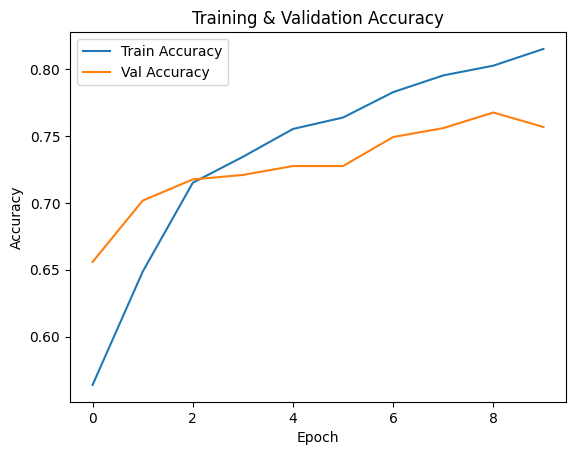

In [14]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training & Validation Accuracy")
plt.show()


38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 280ms/step


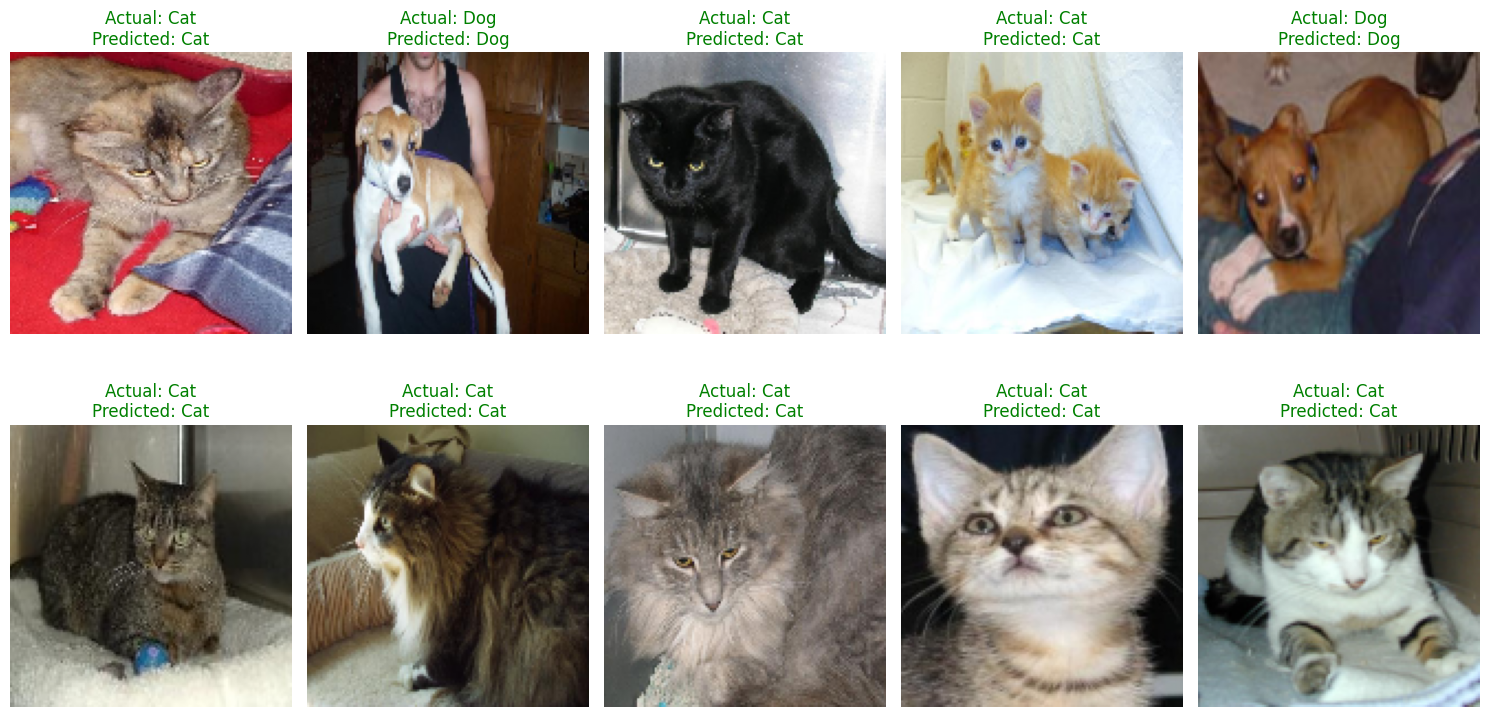

In [16]:
import matplotlib.pyplot as plt

# Number of images to show
num_images = 10

# Get predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

# Label map
label_map = {0: 'Cat', 1: 'Dog'}

# Reshape images back
reshaped_images = X_test.reshape(-1, 128, 128, 3)

# Display
plt.figure(figsize=(15, 8))
for i in range(num_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(reshaped_images[i])
    plt.axis('off')
    actual = label_map[y_test[i]]
    predicted = label_map[y_pred[i]]
    color = 'green' if actual == predicted else 'red'
    plt.title(f"Actual: {actual}\nPredicted: {predicted}", color=color)
plt.tight_layout()
plt.show()

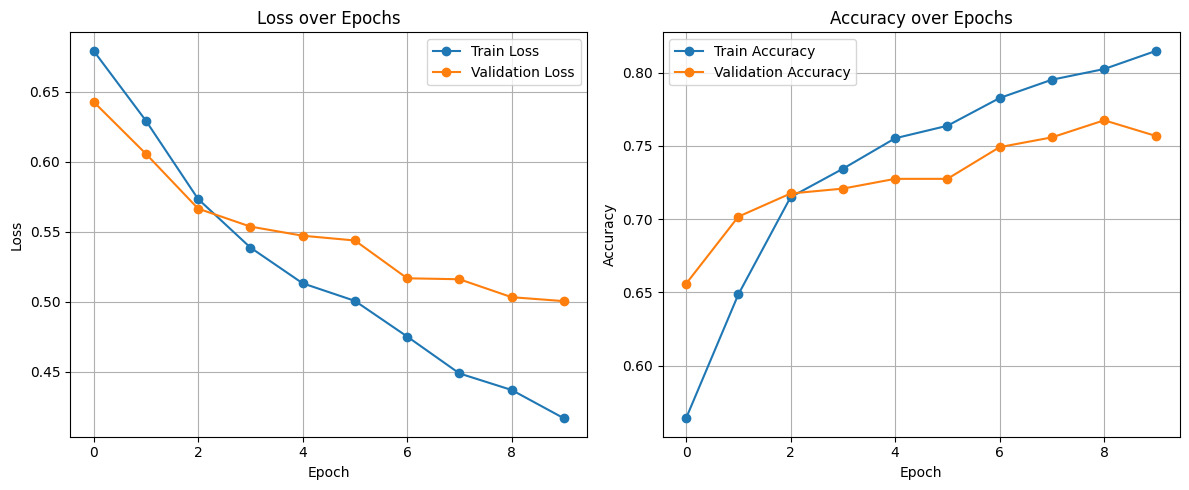

In [17]:
# Training history is stored in 'history' from model.fit()
import matplotlib.pyplot as plt

# Plot Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
